# 📊 Financial Performance Analysis - Python Exploratory Data Analysis (EDA)

## 📌 Project Overview

This notebook performs Exploratory Data Analysis (EDA) on the Microsoft Financial Sample dataset using Python. The objective is to analyze revenue, profitability, products, customer segments, countries, discount strategies, and time-based trends to uncover actionable business insights.

The analysis follows a structured workflow beginning with data loading and quality assessment, followed by data cleaning, feature engineering, exploratory analysis, and visualization. The insights generated in this notebook complement the SQL analysis and support the development of interactive Excel and Power BI dashboards.

---

## 📈 Executive Summary

This analysis identified the key drivers of financial performance across products, countries, customer segments, discount strategies, and seasonal trends.

### Key Highlights

- The United States generated the highest revenue, while France recorded the highest profit.
- Paseo was the top-performing product in both revenue and profitability.
- Government customers contributed the largest share of revenue.
- October was the strongest month for both revenue and profit.
- Low and Medium discount strategies produced higher profits than High discounts.

---

## 🎯 Objectives

- Understand the structure and quality of the financial dataset.
- Perform data cleaning and validation.
- Engineer new financial metrics for deeper analysis.
- Analyze revenue and profit across products, countries, and customer segments.
- Identify the impact of discounts on business profitability.
- Explore monthly and yearly financial trends.
- Create professional visualizations to support business decision-making.

---

## 🛠️ Tools & Libraries

- Python 3
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

---

## 📂 Dataset

**Dataset:** Microsoft Financial Sample

**Records:** 700 Financial Transactions

**Key Features:**
- Segment
- Country
- Product
- Discount Band
- Units Sold
- Manufacturing Price
- Sales Price
- Gross Sales
- Discounts
- Sales
- COGS
- Profit
- Date

---

## 🔄 Analysis Workflow

1. Import Libraries
2. Load Dataset
3. Data Exploration
4. Data Quality Assessment
5. Data Cleaning
6. Feature Engineering
7. Exploratory Data Analysis (EDA)
8. Data Visualization
9. Business Insights
10. Executive Summary & Recommendations

---

**Author:** Sameer Sharma

## 1. Import Required Libraries

The first step is to import the libraries required for data manipulation, analysis, and visualization.

- **Pandas** → Data manipulation and analysis
- **NumPy** → Numerical computations
- **Matplotlib** → Data visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

Load the cleaned financial dataset into a Pandas DataFrame and preview the first few records to verify that the data has been imported correctly.

In [5]:
df = pd.read_csv("Financials.cleaned.csv")

df.head()

,Segment,Country,Product,Discount_Band,Units_Sold,Manufacturing_Price,Sale_Price,Gross_Sales,Discounts,Sales,COGS,Profit,Date,Month_Number,Month_Name,Year
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,0.0,32370.0,16185.0,16185.0,01-01-2014,1,January,2014
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,0.0,26420.0,13210.0,13210.0,01-01-2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,0.0,32670.0,21780.0,10890.0,01-06-2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,0.0,13320.0,8880.0,4440.0,01-06-2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,0.0,37050.0,24700.0,12350.0,01-06-2014,6,June,2014


## 3. Data Exploration

Before beginning the analysis, it is important to understand the structure, size, and characteristics of the dataset.

The following checks provide an overview of:

- Dataset dimensions
- Column names
- Data types
- Summary statistics

In [6]:
df.shape

(700, 16)

In [7]:
df.columns

Index(['Segment', 'Country', ' Product ', ' Discount_Band ', ' Units_Sold ',
       ' Manufacturing_Price ', ' Sale_Price ', ' Gross_Sales ', ' Discounts ',
       '  Sales ', ' COGS ', ' Profit ', 'Date', 'Month_Number',
       ' Month_Name ', 'Year'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Segment                700 non-null    str    
 1   Country                700 non-null    str    
 2    Product               700 non-null    str    
 3    Discount_Band         700 non-null    str    
 4    Units_Sold            700 non-null    float64
 5    Manufacturing_Price   700 non-null    float64
 6    Sale_Price            700 non-null    float64
 7    Gross_Sales           700 non-null    float64
 8    Discounts             700 non-null    float64
 9     Sales                700 non-null    float64
 10   COGS                  700 non-null    float64
 11   Profit                700 non-null    float64
 12  Date                   700 non-null    str    
 13  Month_Number           700 non-null    int64  
 14   Month_Name            700 non-null    str    
 15  Year             

In [10]:
df.describe()

,Units_Sold,Manufacturing_Price,Sale_Price,Gross_Sales,Discounts,Sales,COGS,Profit,Month_Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354671,1.696091e+05,145475.211429,24133.860414,7.900000,2013.750000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928760,2.367263e+05,203865.506118,42760.626547,3.377321,0.433322
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.347500,2.610775e+05,245607.500000,22662.000000,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,12.000000,2014.000000


In [13]:
df.head(10)

,Segment,Country,Product,Discount_Band,Units_Sold,Manufacturing_Price,Sale_Price,Gross_Sales,Discounts,Sales,COGS,Profit,Date,Month_Number,Month_Name,Year
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,0.0,32370.0,16185.0,16185.0,01-01-2014,1,January,2014
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,0.0,26420.0,13210.0,13210.0,01-01-2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,0.0,32670.0,21780.0,10890.0,01-06-2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,0.0,13320.0,8880.0,4440.0,01-06-2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,0.0,37050.0,24700.0,12350.0,01-06-2014,6,June,2014
5,Government,Germany,Carretera,None,1513.0,3.0,350.0,529550.0,0.0,529550.0,393380.0,136170.0,01-12-2014,12,December,2014
6,Midmarket,Germany,Montana,None,921.0,5.0,15.0,13815.0,0.0,13815.0,9210.0,4605.0,01-03-2014,3,March,2014
7,Channel Partners,Canada,Montana,None,2518.0,5.0,12.0,30216.0,0.0,30216.0,7554.0,22662.0,01-06-2014,6,June,2014
8,Government,France,Montana,None,1899.0,5.0,20.0,37980.0,0.0,37980.0,18990.0,18990.0,01-06-2014,6,June,2014
9,Channel Partners,Germany,Montana,None,1545.0,5.0,12.0,18540.0,0.0,18540.0,4635.0,13905.0,01-06-2014,6,June,2014


### Business Insight

- The dataset contains financial transaction records across multiple countries, products, and customer segments.
- Initial exploration confirms the dataset structure and verifies that the data is ready for quality assessment.
- Understanding the dataset at this stage helps ensure reliable analysis in later sections.

## 4. Data Quality Assessment

This section validates the overall quality of the dataset by checking:

- Missing values
- Duplicate records
- Incorrect data types
- Invalid values

Ensuring high-quality data is essential before performing any business analysis.

In [14]:
df.isnull().sum()

Segment                  0
Country                  0
 Product                 0
 Discount_Band           0
 Units_Sold              0
 Manufacturing_Price     0
 Sale_Price              0
 Gross_Sales             0
 Discounts               0
  Sales                  0
 COGS                    0
 Profit                  0
Date                     0
Month_Number             0
 Month_Name              0
Year                     0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.dtypes

Segment                      str
Country                      str
 Product                     str
 Discount_Band               str
 Units_Sold              float64
 Manufacturing_Price     float64
 Sale_Price              float64
 Gross_Sales             float64
 Discounts               float64
  Sales                  float64
 COGS                    float64
 Profit                  float64
Date                         str
Month_Number               int64
 Month_Name                  str
Year                       int64
dtype: object

In [27]:
for col in ['Segment', 'Country', 'Product', 'Discount_Band']:
    print(f"\n{col}")
    print(df[col].unique())


Segment
<StringArray>
['Government', 'Midmarket', 'Channel Partners', 'Enterprise',
 'Small Business']
Length: 5, dtype: str

Country
<StringArray>
['Canada', 'Germany', 'France', 'Mexico', 'United States of America']
Length: 5, dtype: str

Product
<StringArray>
[' Carretera ', ' Montana ', ' Paseo ', ' Velo ', ' VTT ', ' Amarilla ']
Length: 6, dtype: str

Discount_Band
<StringArray>
[' None ', ' Low ', ' Medium ', ' High ']
Length: 4, dtype: str


## 5. Feature Engineering

Feature engineering involves creating new variables from the existing dataset to enhance business analysis. These derived metrics provide deeper insights into profitability, operational efficiency, and sales performance.

### 5.1 Profit Margin (%)

Profit Margin measures the percentage of revenue retained as profit after accounting for costs. It is one of the most important financial KPIs for evaluating business performance.

In [32]:
df["Profit_Margin_%"]=round((df["Profit"]/df["Sales"])*100,2)
df[["Sales","Profit","Profit_Margin_%"]].head()

,Sales,Profit,Profit_Margin_%
0,32370.0,16185.0,50.00
1,26420.0,13210.0,50.00
2,32670.0,10890.0,33.33
3,13320.0,4440.0,33.33
4,37050.0,12350.0,33.33


### 5.2 Revenue per Unit

Revenue per Unit measures the average revenue generated from each unit sold. This metric helps compare product pricing and revenue efficiency across the business.

In [33]:
df["Revenue_per_unit"]=round((df["Sales"]/df["Units_Sold"]),2)
df[["Sales","Units_Sold","Revenue_per_unit"]].head()

,Sales,Units_Sold,Revenue_per_unit
0,32370.0,1618.5,20.0
1,26420.0,1321.0,20.0
2,32670.0,2178.0,15.0
3,13320.0,888.0,15.0
4,37050.0,2470.0,15.0


### 5.3 Profit per Unit

Profit per Unit calculates the average profit earned from each unit sold. It provides a better understanding of product profitability beyond total sales.

In [34]:
df["Profit_per_Unit"] = round(df["Profit"] / df["Units_Sold"], 2)

df[["Units_Sold", "Profit", "Profit_per_Unit"]].head()

,Units_Sold,Profit,Profit_per_Unit
0,1618.5,16185.0,10.0
1,1321.0,13210.0,10.0
2,2178.0,10890.0,5.0
3,888.0,4440.0,5.0
4,2470.0,12350.0,5.0


### 5.4 Quarter

The Quarter feature is extracted from the transaction date to enable quarterly analysis of revenue and profitability. Grouping data by quarters helps identify seasonal trends and supports business reporting.

In [36]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Quarter"] = "Q" + df["Date"].dt.quarter.astype(str)

df[["Date", "Quarter"]].head()

,Date,Quarter
0,2014-01-01,Q1
1,2014-01-01,Q1
2,2014-06-01,Q2
3,2014-06-01,Q2
4,2014-06-01,Q2


### 📊 Business Insight

Feature engineering enhanced the dataset by creating additional financial metrics such as Profit Margin, Revenue per Unit, Profit per Unit, and Quarter. These derived features provide deeper insights into business performance and will support the exploratory analysis in the following sections.

# 6. Exploratory Data Analysis (EDA)

This section explores the financial performance of the business through visualizations and descriptive analysis. The objective is to identify trends, compare performance across business dimensions, and generate actionable business insights.

Each visualization answers a specific business question and highlights key findings from the dataset.

### Business Question 1

**Which countries generate the highest revenue?**

This analysis compares total revenue across countries to identify the strongest-performing markets.

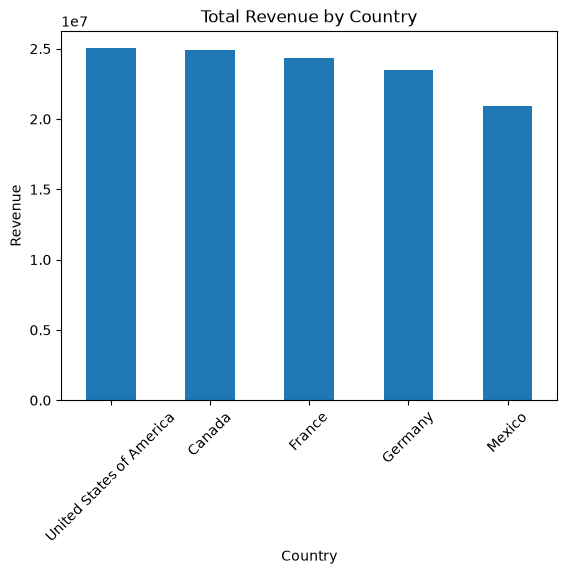

In [37]:
Country_Sales= df.groupby("Country")["Sales"].sum().sort_values(ascending=False)

Country_Sales.plot(kind="bar")
plt.title("Total Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

### 📊 Business Insight

- The United States of America generated the highest total revenue, making it the largest revenue-contributing market.
- Canada and France also contributed significantly, indicating strong market demand.
- Mexico recorded the lowest revenue among the five countries, suggesting comparatively lower sales performance.
- The relatively balanced revenue across countries indicates a geographically diversified customer base rather than dependence on a single market.

### Business Question 2

**Which countries generate the highest profit?**

Revenue alone does not indicate business success. This analysis evaluates profitability across countries.

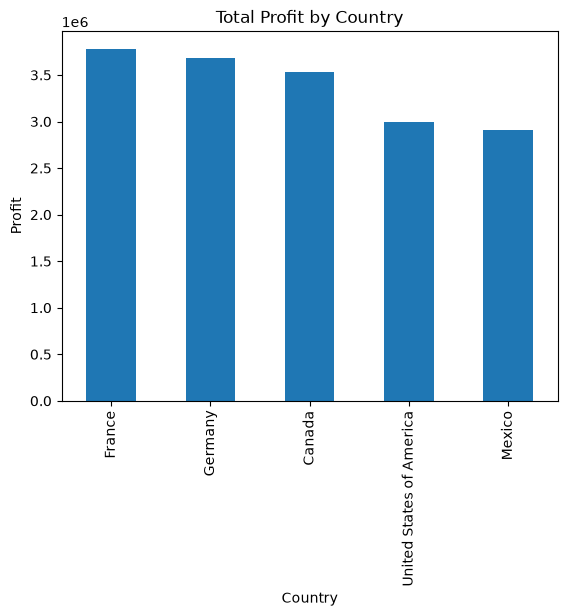

In [39]:
Country_Profit=df.groupby("Country")["Profit"].sum().sort_values(ascending=False)

Country_Profit.plot(kind="bar")
plt.title("Total Profit by Country")
plt.xlabel("Country")
plt.ylabel("Profit")

plt.show()

### 📊 Business Insight

- France generated the highest overall profit despite not having the highest revenue, indicating better profitability and cost efficiency.
- Germany and Canada also delivered strong profits, making them important contributors to overall business earnings.
- The United States generated the highest revenue but ranked lower in profit than France, suggesting comparatively lower profit margins.
- Mexico produced the lowest profit, highlighting an opportunity to improve pricing, cost management, or sales strategy in that market.

### Business Question 3

**Which products generate the highest revenue?**

Understanding product-level revenue helps identify the strongest contributors to business growth.

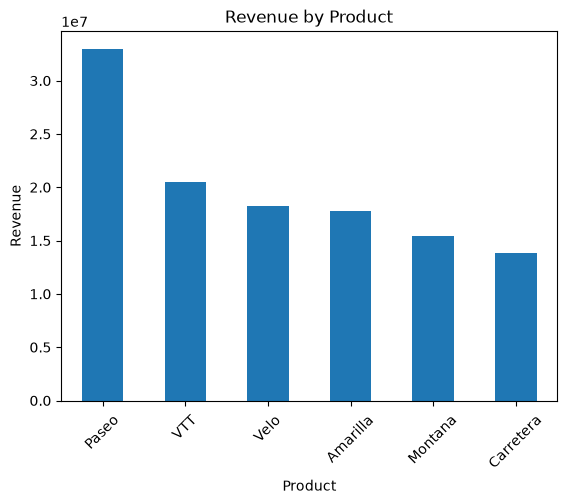

In [40]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

product_sales.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

### 📊 Business Insight

- Paseo is the highest revenue-generating product, making it the company's primary revenue driver.
- VTT and Velo are the next strongest contributors, forming a significant share of overall sales.
- Carretera generated the lowest revenue among all products, indicating comparatively weaker market demand.
- Revenue is concentrated among the top-performing products, suggesting that product portfolio performance is uneven.

### Business Question 4

**Which products generate the highest profit?**

High revenue does not always translate into high profitability. This analysis identifies the products that contribute the most profit.

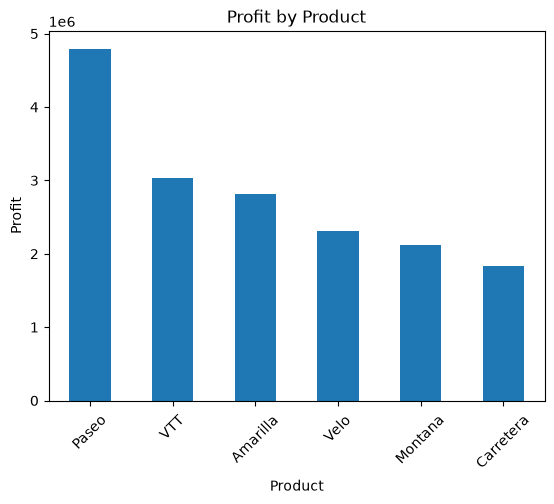

In [41]:
product_profit = df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

product_profit.plot(kind="bar")

plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.show()

### 📊 Business Insight

- Paseo is also the most profitable product, demonstrating strong financial performance in both revenue generation and profitability.
- VTT and Amarilla deliver substantial profits, making them valuable products for long-term business growth.
- Carretera contributes the least profit, indicating lower profitability compared to the rest of the product portfolio.
- Comparing revenue and profit shows that not all high-selling products generate the same level of profit, highlighting the importance of evaluating both metrics when making product decisions.

### Business Question 5

**Which customer segment generates the highest revenue?**

Customer segmentation helps identify the most valuable customer groups and supports targeted business strategies.

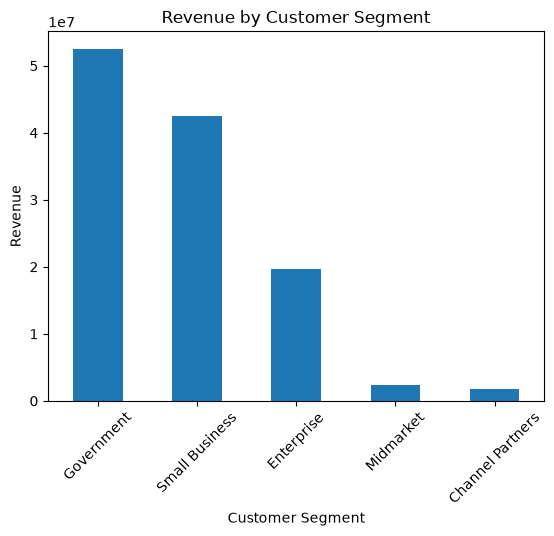

In [42]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

segment_sales.plot(kind="bar")

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

### 📊 Business Insight

- Government is the highest revenue-generating customer segment, contributing the largest share of total sales.
- Small Business is the second-largest contributor, indicating strong demand from smaller organizations.
- Enterprise customers generate moderate revenue, while Midmarket and Channel Partners contribute only a small proportion of overall sales.
- The business appears to rely heavily on Government and Small Business customers, suggesting an opportunity to diversify revenue across other customer segments.

### Business Question 6

**How does revenue vary across different months?**

Analyzing monthly revenue trends helps identify seasonality and periods of peak business activity.

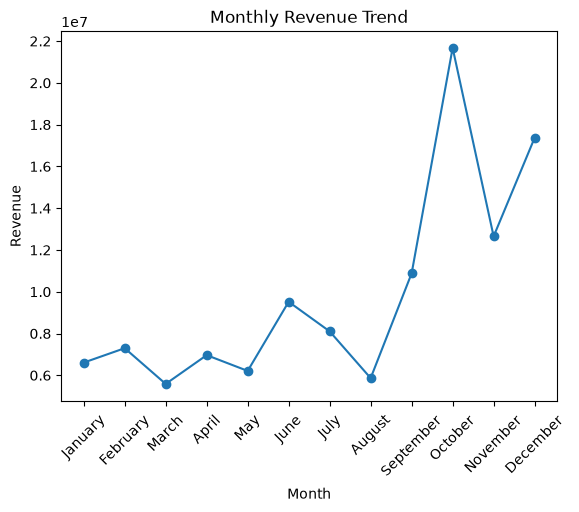

In [58]:
monthly_sales = (
    df.groupby(["Month_Number", "Month_Name"], as_index=False)["Sales"]
      .sum()
      .sort_values("Month_Number")
)


plt.plot(
    monthly_sales["Month_Name"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### 📊 Business Insight

- Revenue remained relatively stable during the first eight months of the year before increasing sharply in September and peaking in October.
- October recorded the highest monthly revenue, indicating a significant seasonal sales surge.
- Revenue declined after October but remained comparatively strong in November and December.
- The noticeable increase in Q4 suggests that business demand is highest toward the end of the year, making this period critical for inventory planning and marketing campaigns.

### Business Question 7

**How does profitability change over time?**

Monitoring monthly profit trends helps evaluate financial performance beyond sales volume.

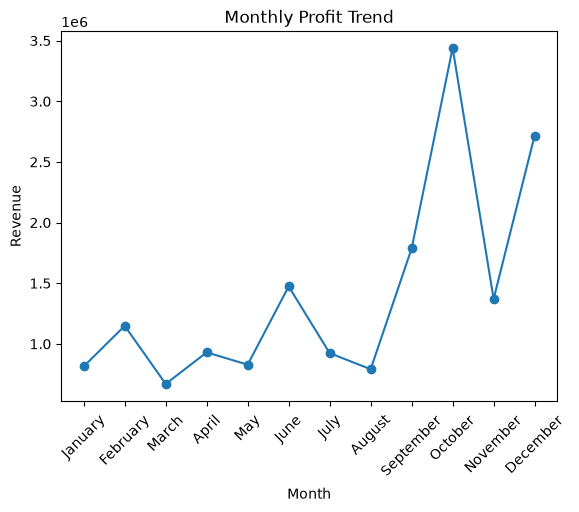

In [63]:
monthly_profit = (
    df.groupby(["Month_Number", "Month_Name"], as_index=False)["Profit"]
      .sum()
      .sort_values("Month_Number")
)


plt.plot(
    monthly_profit["Month_Name"],
    monthly_profit["Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### 📊 Business Insight

- Monthly profit closely follows the overall revenue trend, with the highest profit recorded in October.
- Profitability increased substantially during the final quarter of the year, indicating stronger financial performance despite seasonal fluctuations.
- March and August recorded comparatively lower profits, suggesting weaker business performance during these months.
- The strong correlation between revenue and profit indicates that increased sales generally translated into higher earnings throughout the year.

### Business Question 8

**How do different discount levels affect profitability?**

This analysis evaluates whether increasing discounts improves sales without significantly reducing profits.

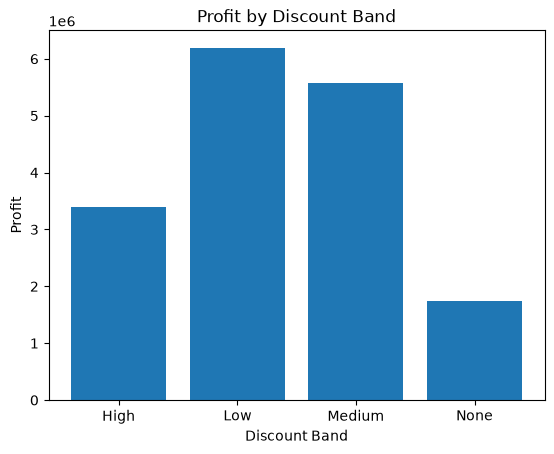

In [66]:
discount_profit = (
    df.groupby("Discount_Band", as_index=False)["Profit"]
      .sum()
)

plt.bar(
    discount_profit["Discount_Band"],
    discount_profit["Profit"])

plt.title("Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Profit")

plt.show()

### 📊 Business Insight

- Transactions with Low discounts generated the highest overall profit, indicating that moderate discounting can effectively balance sales growth and profitability.
- Medium discount transactions also contributed significantly to total profit.
- Surprisingly, transactions with no discount generated the lowest profit, suggesting that discounts may have helped increase sales volume enough to offset reduced margins.
- High discounts produced lower profits than Low and Medium discounts, highlighting the importance of optimizing discount strategies rather than offering excessive price reductions.

### Business Question 9

**Which financial metrics are most closely related?**

Correlation analysis helps identify relationships between numerical variables such as Sales, Profit, Discounts, Units Sold, and Manufacturing Price. Understanding these relationships supports better business decisions and helps identify key drivers of profitability.

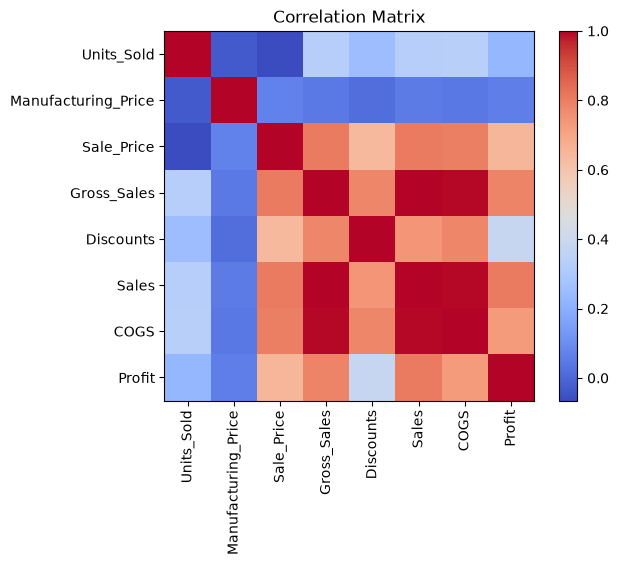

In [68]:
correlation = df[[
    "Units_Sold",
    "Manufacturing_Price",
    "Sale_Price",
    "Gross_Sales",
    "Discounts",
    "Sales",
    "COGS",
    "Profit"
]].corr()

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")
plt.show()

### 📊 Business Insight

- Sales, Gross Sales, and COGS exhibit a very strong positive correlation, indicating that these financial metrics move closely together.
- Profit is strongly positively correlated with Sales, suggesting that higher sales generally result in greater profitability.
- Discounts show a moderate positive relationship with Sales and Gross Sales, indicating that discount strategies influence overall sales performance.
- Manufacturing Price has a relatively weak relationship with most financial metrics, implying that product pricing and sales volume have a greater impact on business performance than manufacturing cost alone.

### Business Question 10

**Does higher revenue consistently translate into higher profit?**

A scatter plot helps visualize the relationship between revenue and profit while identifying any unusual transactions or outliers.

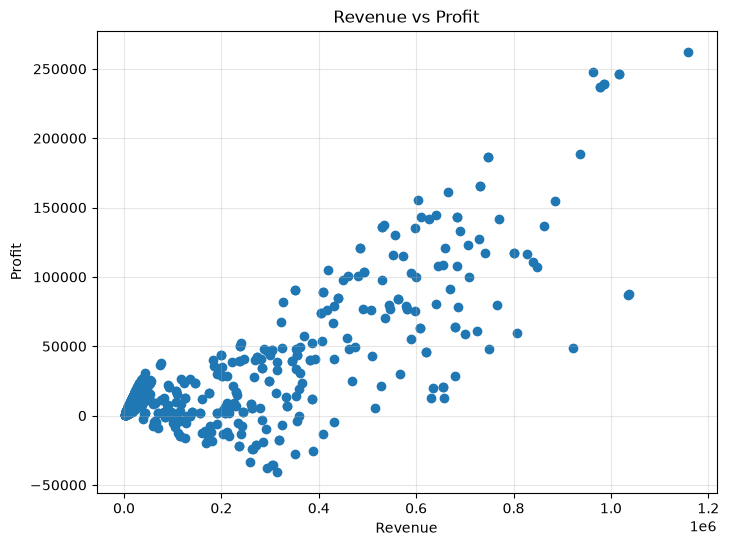

In [70]:
plt.figure(figsize=(8,6))

plt.scatter(df["Sales"], df["Profit"])

plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")

plt.grid(alpha=0.3)

plt.show()

### 📊 Business Insight

- The scatter plot shows a clear positive relationship between Revenue and Profit, indicating that higher revenue generally leads to higher profitability.
- Most transactions follow an upward trend, suggesting consistent financial performance across the dataset.
- A few high-revenue transactions generate exceptionally high profits, representing the company's most valuable sales opportunities.
- Some high-revenue transactions produce comparatively lower profits, indicating that factors such as discounts or higher costs may reduce profit margins despite strong sales.

# 7. Key Findings

## Executive Summary

The exploratory data analysis revealed several important insights into the company's financial performance across countries, products, customer segments, discount strategies, and time periods.

### Key Findings

- The United States generated the highest overall revenue, while France achieved the highest profit, highlighting differences between sales volume and profitability.
- Paseo emerged as the best-performing product, leading both revenue and profit generation.
- Government customers contributed the highest revenue, followed by Small Business, making these the company's most valuable customer segments.
- Revenue and profit increased significantly during the fourth quarter, with October recording the strongest financial performance.
- Low and Medium discount strategies generated higher overall profits than High discounts, suggesting that moderate discounting is more effective than aggressive price reductions.
- Correlation analysis confirmed a strong positive relationship between Sales and Profit.
- The Revenue vs Profit scatter plot demonstrated that increased revenue generally translated into higher profitability, although a few transactions achieved lower profits despite high sales.

# 8. Business Recommendations

Based on the analysis, the following recommendations can help improve financial performance:

- Continue investing in high-performing products such as Paseo while evaluating opportunities to improve the performance of lower-selling products.
- Strengthen customer relationships within the Government and Small Business segments, which contribute the highest revenue.
- Increase inventory and marketing efforts before the fourth quarter to capitalize on seasonal demand.
- Optimize discount strategies by focusing on Low and Medium discount levels rather than excessive discounting.
- Investigate high-revenue transactions with relatively low profits to identify opportunities for improving profit margins.
- Monitor product profitability alongside sales performance to support more informed business decisions.

# 9. Conclusion

This notebook presented a complete Exploratory Data Analysis (EDA) of the Microsoft Financial Sample dataset using Python.

The analysis covered data exploration, quality assessment, feature engineering, visualization, and business insight generation. Through multiple visualizations and financial metrics, the project identified key revenue drivers, profitable products, customer segment performance, seasonal trends, and the impact of discount strategies.

Overall, this project demonstrates the complete Python analytics workflow—from raw data exploration to actionable business insights—and complements the SQL, Excel, and Power BI analyses within this end-to-end Financial Performance Analysis project.

### Thank you for exploring this project!

**Author:** Sameer Sharma